# Умный модератор комментариев 2.0

## Цель проекта

Цель проекта - разработать современную систему автоматической классификации комментариев на токсичные и нетоксичные с использованием трансформерной модели RuBERT.

В отличие от классического подхода TF-IDF + Logistic Regression, в данном проекте используется предобученная нейронная сеть семейства BERT, позволяющая учитывать контекст слов и смысл всего предложения.

Дополнительно будет реализован REST API на FastAPI, позволяющий использовать модель как отдельный сервис.

---

## Задачи проекта

- исследовать датасет;
- подготовить данные для обучения;
- выполнить токенизацию текста;
- дообучить модель RuBERT;
- оценить качество модели;
- сравнить результаты с классической Logistic Regression;
- сохранить модель;
- реализовать REST API.

# 1. Импорт библиотек

Импортируем библиотеки, необходимые для загрузки данных, обучения модели, оценки качества и визуализации результатов.

In [126]:
import warnings
warnings.filterwarnings("ignore")

import evaluate
from transformers import TrainingArguments
from transformers import DataCollatorWithPadding
from transformers import Trainer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

from datasets import Dataset

# 2. Проверка устройства

Определим, какое устройство будет использоваться для обучения модели.

Если доступно ускорение Apple Silicon (MPS), обучение будет выполняться на GPU.

In [7]:
if torch.backends.mps.is_available():
    device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

Используемое устройство: cpu


# 3. Загрузка и исследование данных

Перед обучением модели необходимо изучить датасет.

На данном этапе проверим:

- размер набора данных;
- наличие пропусков;
- баланс классов;
- примеры комментариев;
- длину комментариев.

Это позволит лучше понять данные и заранее выявить возможные проблемы.

In [9]:
df=pd.read_csv('/Users/igormatevosov/Desktop/smart-toxic-classifier/data/labeled.csv')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   comment  14412 non-null  str    
 1   toxic    14412 non-null  float64
dtypes: float64(1), str(1)
memory usage: 4.6 MB


In [11]:
df.isna().sum()

comment    0
toxic      0
dtype: int64

### Проверка пропусков

Для корректного обучения модели необходимо убедиться, что в данных отсутствуют пропущенные значения.

При наличии пропусков их потребуется удалить или обработать.

In [12]:
df.sample(10)

,comment,toxic
13541,"Дом.рф - это государственная контора, бывшее А...",0.0
5128,мне МЧС набор больше нравится. хотя на вкус и ...,0.0
11657,Ожирение 1й степени как минимум судя по пропор...,0.0
13231,Это они ещё не придумали трудовые повинности в...,0.0
7729,"Как я уже сказала, продукция этого завода не с...",0.0
9966,Странно...пост уже час висит а эту пикчу тольк...,0.0
13182,госпади! негра делают человеком!\n,1.0
5338,Остается вопрос- при внедрении систем защиты п...,0.0
7424,"Повар - расист, а не трап.\n",1.0
6692,"И именно эти неработающие весы показывают, что...",0.0


### Первичный анализ

Просмотр случайных комментариев позволяет понять структуру текста, наличие жаргона, нецензурной лексики, ссылок, эмодзи и других особенностей датасета.

In [13]:
class_counts = df["toxic"].value_counts()

class_counts

toxic
0.0    9586
1.0    4826
Name: count, dtype: int64

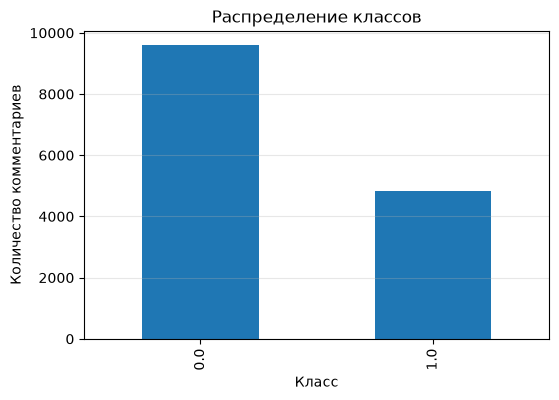

In [114]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество комментариев")
plt.grid(axis="y", alpha=0.3)
plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Анализ распределения классов

Перед обучением модели важно оценить баланс классов.

При сильном дисбалансе модель может чаще предсказывать наиболее распространенный класс, что ухудшает качество классификации.

In [15]:
df["length"] = df["comment"].str.len()

In [16]:
df["length"].describe()

count    14412.000000
mean       176.525812
std        271.612376
min         21.000000
25%         57.000000
50%        101.000000
75%        197.000000
max       7404.000000
Name: length, dtype: float64

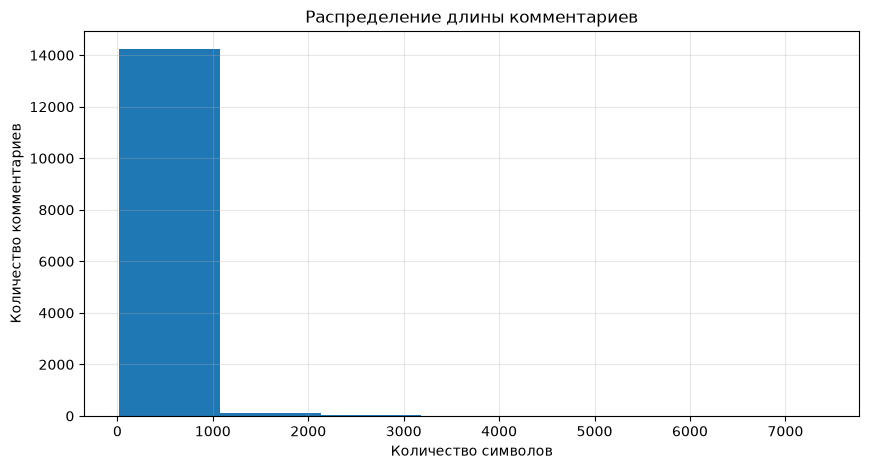

In [17]:
plt.figure(figsize=(10,5))
plt.hist(df["length"], bins=7)
plt.title("Распределение длины комментариев")
plt.xlabel("Количество символов")
plt.ylabel("Количество комментариев")
plt.grid(alpha=0.3)
plt.show()

### Анализ длины комментариев

Большинство современных трансформерных моделей имеют ограничение на максимальную длину входного текста.

Поэтому важно оценить распределение длин комментариев, чтобы в дальнейшем выбрать подходящее значение параметра `max_length`.

In [18]:
df.sort_values("length", ascending=False).head(10)

,comment,toxic,length
2064,С начала года свыше 40 тысяч россиян объявили ...,0.0,7404
3016,"Блеаадь, как же обидно когда создаешь тред, па...",1.0,5218
5795,С 19 апреля в Николаеве будет действовать запр...,0.0,5174
1953,"В Киеве на вокзале Мен було рок в 19, коли мен...",1.0,4921
13688,Агентство DARPA в 2020 году планирует начать р...,0.0,4544
214,"Раз уж вакханалия продолжается, давайте в этом...",0.0,4371
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1.0,4214
9205,"Рад, что Вы допускаете пользу от маркетинга. В...",0.0,4177
659,"Знаете, моя подруга живёт с мужчиной, который ...",1.0,3928
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1.0,3805


In [19]:
df.sort_values("length").head(10)

,comment,toxic,length
1595,Я бы Тармашева забрал,0.0,21
1893,Бауманка астанавитесь,0.0,21
1737,ПАПИЧ ЛУЧШИЙ НА ТРИПЛ,1.0,21
1388,Малышь (подвегаеться),0.0,21
1855,Не читай так больше)),0.0,21
1842,но она же красивая...,0.0,21
1197,залупа из лиственницы,1.0,21
1299,А сколько у нас шпаг?,0.0,21
1124,Ничего он не узнал )),0.0,21
1084,"После маски,лицо жмет",0.0,21


# 4. Подготовка данных

Для моделей семейства BERT не требуется классическая предобработка текста (удаление стоп-слов, стемминг, лемматизация).

Предобученная модель самостоятельно учитывает форму слов, порядок слов и контекст предложения.

Поэтому в данном проекте исходный текст будет использоваться практически без изменений.

In [20]:
df = df[["comment", "toxic"]].copy()

In [21]:
df.dtypes

comment        str
toxic      float64
dtype: object

In [22]:
df["toxic"] = df["toxic"].astype(int)

In [23]:
df.head()

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1
1,"Хохлы, это отдушина затюканого россиянина, мол...",1
2,Собаке - собачья смерть\n,1
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1


In [24]:
train_df,test_df=train_test_split(df, random_state=42, test_size=0.2, stratify=df["toxic"])

In [25]:
print(f"Обучающая выборка: {len(train_df)}")
print(f"Тестовая выборка: {len(test_df)}")

Обучающая выборка: 11529
Тестовая выборка: 2883


In [26]:
print(train_df["toxic"].value_counts(normalize=True))

print('-'*35)

print(test_df["toxic"].value_counts(normalize=True))

toxic
0    0.665105
1    0.334895
Name: proportion, dtype: float64
-----------------------------------
toxic
0    0.665279
1    0.334721
Name: proportion, dtype: float64


# 5. Токенизация текста

Нейронная сеть не может работать напрямую со строками.

Поэтому текст преобразуется в последовательность специальных токенов с помощью токенизатора RuBERT.

На этом этапе будут:

- загружен токенизатор;
- выбрана максимальная длина последовательности;
- выполнено преобразование текста в числовое представление.

In [27]:
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [28]:
token_lengths = df["comment"].apply(
    lambda text: len(tokenizer.tokenize(text))
)

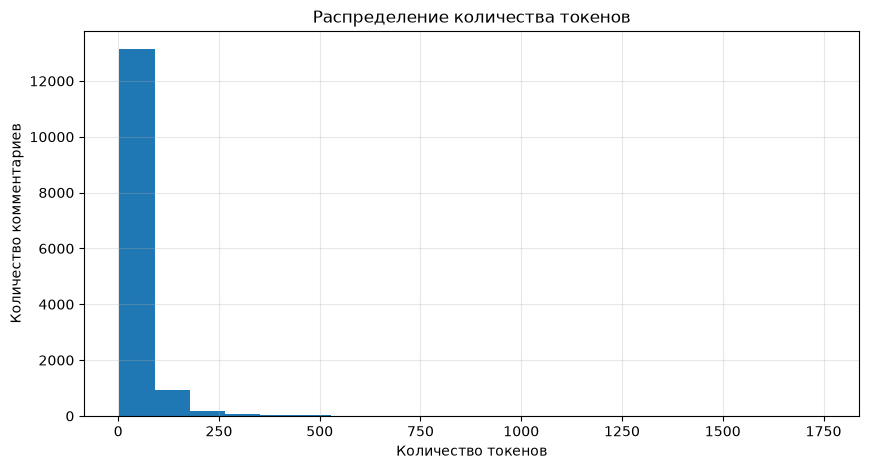

In [118]:
plt.figure(figsize=(10,5))
plt.hist(token_lengths, bins=20)
plt.title("Распределение количества токенов")
plt.xlabel("Количество токенов")
plt.ylabel("Количество комментариев")
plt.grid(alpha=0.3)
plt.savefig(
    "../images/token_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [30]:
print(token_lengths.quantile(0.90))
print(token_lengths.quantile(0.95))
print(token_lengths.quantile(0.99))

85.0
122.0
265.8899999999994


Выбираем **max_length = 128**

- покрываем более 95% комментариев полностью;
- обучение будет заметно быстрее, чем при 256 или 512;
- для задачи бинарной классификации это разумный компромисс.

# 6. Подготовка данных для обучения

Для обучения модели Hugging Face используется объект `Dataset`.

На данном этапе обучающая и тестовая выборки преобразуются из `pandas.DataFrame` в формат `Dataset`, после чего будет выполнена токенизация текста.

In [31]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['comment', 'toxic'],
    num_rows: 11529
})
Dataset({
    features: ['comment', 'toxic'],
    num_rows: 2883
})


**Dataset:**
 - быстрее работает с большими данными;
 - поддерживает батчи;
 - умеет лениво применять преобразования (map);
 - напрямую интегрируется с Trainer

In [32]:
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["comment"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [33]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/11529 [00:00<?, ? examples/s]

Map:   0%|          | 0/2883 [00:00<?, ? examples/s]

In [34]:
print('TRAIN\n',{train_dataset})

print('TEST\n',{test_dataset})


TRAIN
 {Dataset({
    features: ['comment', 'toxic', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 11529
})}
TEST
 {Dataset({
    features: ['comment', 'toxic', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2883
})}


In [35]:
train_dataset = train_dataset.rename_column("toxic", "labels")
test_dataset = test_dataset.rename_column("toxic", "labels")

In [36]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

# 7. Обучение модели RuBERT

На предыдущих этапах данные были подготовлены и преобразованы в формат, необходимый для библиотеки Hugging Face.

Теперь загрузим предобученную модель RuBERT для бинарной классификации текста, настроим параметры обучения и выполним fine-tuning на нашем датасете.

Использование предобученной модели позволяет учитывать контекст слов и значительно улучшить качество классификации по сравнению с классическими методами машинного обучения.

In [37]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

print(model.__class__.__name__) 

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


In [38]:
print(next(model.parameters()).device)

cpu


## Функция оценки качества

Во время обучения модель будет оцениваться по нескольким метрикам.

Основной метрикой проекта является **F1-score**, так как она учитывает одновременно Precision и Recall.

Дополнительно будут рассчитываться Accuracy, Precision и Recall.

In [125]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

In [40]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    precision = precision_metric.compute(
        predictions=predictions,
        references=labels
    )["precision"]

    recall = recall_metric.compute(
        predictions=predictions,
        references=labels
    )["recall"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )["f1"]

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Параметры обучения

Перед запуском обучения необходимо определить основные гиперпараметры модели.

Для данного проекта используются:

- размер батча;
- количество эпох;
- скорость обучения;
- стратегия сохранения лучшей модели;
- оценка качества после каждой эпохи.

In [42]:
training_args = TrainingArguments(

    output_dir="../models/checkpoints",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=2,

    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_dir="../logs",

    logging_steps=100,

    report_to="none",

    dataloader_num_workers=0,

    dataloader_pin_memory=False,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Почему batch_size = 2 и gradient_accumulation_steps = 4

На MacBook с чипом M3 и 8 ГБ общей памяти видеопамять для MPS ограничена. Стандартные батчи (16 или даже 8) приводят к ошибке `MPS backend out of memory`.

**Поэтому выбрано:**
- `batch_size = 2` — чтобы уложиться в память.
- `gradient_accumulation_steps = 4` — чтобы эффективный батч был `2 × 4 = 8`.

Это сохраняет стабильность обучения без потери качества. На более мощных системах параметры можно увеличить.

# 8. Подготовка батчей

Комментарии имеют разную длину, поэтому перед передачей в модель необходимо привести их к одинаковому размеру.

Вместо добавления заполнения (`padding`) ко всему датасету используется динамический padding.

Такой подход уменьшает расход памяти и ускоряет обучение модели.

In [44]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [46]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

# 9. Обучение модели

После подготовки модели и параметров обучения запускается процесс fine-tuning.

Во время обучения после каждой эпохи будут рассчитываться основные метрики качества, а также автоматически сохраняться лучшая версия модели.

In [47]:
model = model.to("cpu")

In [48]:
print(next(model.parameters()).device)  # Должно быть cpu

cpu


In [49]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.050746,0.370175,0.907041,0.868783,0.850777,0.859686
2,1.170117,0.386720,0.912244,0.871608,0.865285,0.868435
3,1.140741,0.401115,0.915366,0.865248,0.884974,0.875000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4326, training_loss=1.1367461243769221, metrics={'train_runtime': 1108.9795, 'train_samples_per_second': 31.188, 'train_steps_per_second': 3.901, 'total_flos': 26980365370692.0, 'train_loss': 1.1367461243769221, 'epoch': 3.0})

In [50]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.140741,0.401115,3,0.915366,0.865248,0.884974,0.875000


{'eval_loss': 0.4011150896549225,
 'eval_accuracy': 0.9153659382587582,
 'eval_precision': 0.8652482269503546,
 'eval_recall': 0.8849740932642487,
 'eval_f1': 0.875}

## Оценка качества модели

После обучения проверяем модель на тестовой выборке.

Используем:
- Classification Report
- Confusion Matrix
- Precision / Recall / F1-score
- анализ ошибок модели

In [51]:
predictions = trainer.predict(test_dataset)

predictions

PredictionOutput(predictions=array([[ 3.4704769, -3.3496428],
       [ 3.0200582, -2.8888857],
       [-2.7952015,  2.7739222],
       ...,
       [ 3.4710302, -3.4130244],
       [-2.825785 ,  2.8299963],
       [ 1.2585553, -1.185778 ]], shape=(2883, 2), dtype=float32), label_ids=array([0, 0, 1, ..., 0, 1, 0], shape=(2883,)), metrics={'test_loss': 0.4011150896549225, 'test_accuracy': 0.9153659382587582, 'test_precision': 0.8652482269503546, 'test_recall': 0.8849740932642487, 'test_f1': 0.875, 'test_runtime': 16.3248, 'test_samples_per_second': 176.603, 'test_steps_per_second': 88.332})

In [52]:
y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

print(y_true[:10])
print(y_pred[:10])

[0 0 1 0 1 0 1 1 0 1]
[0 0 1 1 1 0 1 1 1 1]


## Classification Report

Показывает качество модели по каждому классу отдельно.

Особенно важны:
- precision — насколько редко модель ошибочно обвиняет нормальные комментарии;
- recall — насколько хорошо находит токсичные комментарии;
- f1-score — баланс между ними.

In [124]:
report = classification_report(
    true_labels,
    predictions,
    target_names=[
        "non-toxic",
        "toxic"
    ],
    output_dict=True
)


report_df = pd.DataFrame(report).transpose()
report_df.to_csv(
    "../images/classification_report.csv"
)

report_df


,precision,recall,f1-score,support
non-toxic,0.941456,0.930657,0.936025,1918.000000
toxic,0.865248,0.884974,0.875000,965.000000
accuracy,0.915366,0.915366,0.915366,0.915366
macro avg,0.903352,0.907816,0.905513,2883.000000
weighted avg,0.915947,0.915366,0.915599,2883.000000


## Confusion Matrix

Матрица ошибок показывает,
какие типы ошибок совершает модель.

Особенно важно:
- False Positive — нормальный комментарий определен как токсичный;
- False Negative — токсичный комментарий пропущен.

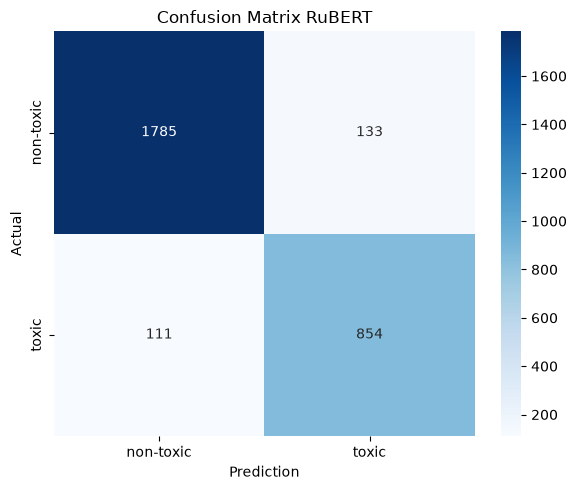

In [123]:
cm = confusion_matrix(
    true_labels,
    predictions
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "non-toxic",
        "toxic"
    ],
    yticklabels=[
        "non-toxic",
        "toxic"
    ]
)


plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix RuBERT")


plt.tight_layout()


plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Precision-Recall Curve

Позволяет посмотреть,
как меняется качество модели
при изменении порога классификации.

Это особенно важно для системы модерации,
где цена ошибочной блокировки высокая.

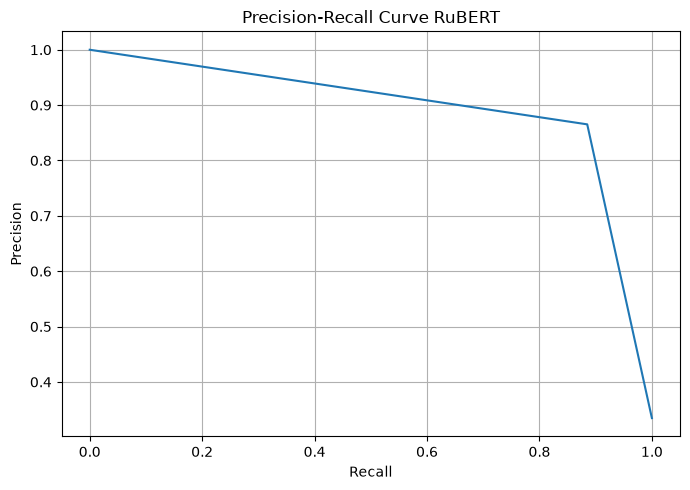

In [122]:
precision, recall, thresholds = precision_recall_curve(
    true_labels,
    predictions
)


plt.figure(figsize=(7,5))


plt.plot(
    recall,
    precision
)


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve RuBERT")

plt.grid()


plt.tight_layout()


plt.savefig(
    "../images/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Проверка на собственных примерах

Проверяем способность модели понимать разные типы сообщений:
- обычные сообщения;
- оскорбления;
- позитивные сообщения;
- короткие фразы.

In [89]:
def predict(text):

    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )


    for key in inputs:
        inputs[key] = inputs[key].to("mps")


    with torch.no_grad():

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )


    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )


    toxic_probability = probabilities[0][1].item()


    return {
        "text": text,
        "toxic": toxic_probability > 0.5,
        "confidence": round(toxic_probability, 3)
    }

In [92]:
examples = [
    "привет",
    "как дела?",
    "ты молодец",
    "спасибо большое",
    "ты полный идиот",
    "ненавижу тебя",
    "какой ужасный человек"
]


for text in examples:
    print(predict(text))

{'text': 'привет', 'toxic': False, 'confidence': 0.011}
{'text': 'как дела?', 'toxic': False, 'confidence': 0.002}
{'text': 'ты молодец', 'toxic': True, 'confidence': 0.996}
{'text': 'спасибо большое', 'toxic': False, 'confidence': 0.001}
{'text': 'ты полный идиот', 'toxic': True, 'confidence': 0.998}
{'text': 'ненавижу тебя', 'toxic': True, 'confidence': 0.993}
{'text': 'какой ужасный человек', 'toxic': True, 'confidence': 0.994}


## Оценка модели RuBERT на тестовой выборке

На этом этапе модель делает предсказания для всех объектов тестовой выборки.
После этого сравниваем предсказанные значения с настоящими метками.

In [120]:
model.eval()


predictions = []
true_labels = []


for item in test_dataset:

    inputs = {
        "input_ids": item["input_ids"].unsqueeze(0).to("mps"),
        "attention_mask": item["attention_mask"].unsqueeze(0).to("mps")
    }


    with torch.no_grad():

        outputs = model(**inputs)


    probs = torch.softmax(
        outputs.logits,
        dim=1
    )


    prediction = torch.argmax(
        probs,
        dim=1
    ).item()


    predictions.append(prediction)

    true_labels.append(
        item["labels"]
    )


print("Количество предсказаний:", len(predictions))
print("Количество настоящих меток:", len(true_labels))

Количество предсказаний: 2883
Количество настоящих меток: 2883


In [121]:
metrics_df = pd.DataFrame({
    "Model": ["RuBERT"],
    "Accuracy": [accuracy_score(true_labels, predictions)],
    "Precision": [precision_score(true_labels, predictions)],
    "Recall": [recall_score(true_labels, predictions)],
    "F1-score": [f1_score(true_labels, predictions)]
})

metrics_df.to_csv(
    "../images/rubert_metrics.csv",
    index=False
)
metrics_df

,Model,Accuracy,Precision,Recall,F1-score
0,RuBERT,0.915366,0.865248,0.884974,0.875


# ⚖️ Comparison of Models

В проекте были протестированы два подхода для классификации токсичных комментариев:

1. **TF-IDF + Logistic Regression**  
   Базовая модель, которая использует статистические признаки слов.  
   Она хорошо работает с частыми словами, но не учитывает контекст предложения.

2. **RuBERT (Transformer model)**  
   Предобученная языковая модель для русского языка, которая учитывает контекст слов и смысл предложения.

Обе модели были протестированы на одинаковой тестовой выборке.

## Результаты сравнения

| Model | Accuracy | Precision | Recall | F1-score |
|------|----------|-----------|--------|----------|
| TF-IDF + Logistic Regression | 0.876 | 0.807 | 0.813 | 0.810 |
| RuBERT | 0.915 | 0.865 | 0.885 | 0.875 |

## Вывод

Использование трансформерной модели RuBERT позволило улучшить качество классификации:

- Accuracy увеличилась примерно на **4%**.
- Precision вырос на **5.8%**.
- Recall вырос на **7.2%**.
- F1-score увеличился примерно на **6.5%**.

Главное преимущество RuBERT заключается в способности учитывать контекст сообщения.

Например, TF-IDF модель может воспринимать отдельное слово как токсичное без учета смысла, в то время как Transformer анализирует взаимосвязь слов в предложении.

In [110]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "RuBERT"
    ],
    "Accuracy": [
        0.8758,
        0.9154
    ],
    "Precision": [
        0.8074,
        0.8652
    ],
    "Recall": [
        0.8126,
        0.8850
    ],
    "F1-score": [
        0.8100,
        0.8750
    ]
})

comparison.to_csv(
    "../images/model_comparison.csv",
    index=False
)
comparison

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.8758,0.8074,0.8126,0.810
1,RuBERT,0.9154,0.8652,0.8850,0.875


In [127]:
model.save_pretrained("../models/rubert-toxic")
tokenizer.save_pretrained("../models/rubert-toxic")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/rubert-toxic/tokenizer_config.json',
 '../models/rubert-toxic/tokenizer.json')